### Importing necessary libraries

In [1]:
# import torch and some of its submodules
import torch
from torch import nn

# import torchvision and some of its submodules
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# import matplotlib for plotting
import matplotlib.pyplot as plt

In [2]:
# print version of torch and torchvision
print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

torch version: 2.7.1+cu118
torchvision version: 0.22.1+cu118


### Getting a dataset (FashionMNIST Dataset)

In [3]:
# dataset used is FashionMNIST

# set up training data
train_data = datasets.FashionMNIST(
    root="data", # where to download the data 
    train=True, # training data
    download=True, # download the data
    transform=ToTensor(), # how to transform the data
    target_transform=None, # how to transform the labels
)

# set up test data
test_data = datasets.FashionMNIST(
    root="data", # where to download the data 
    train=False, # test data
    download=True, # download the data
    transform=ToTensor(), # how to transform the data
    target_transform=None, # how to transform the labels
)

### Checking number of samples in train and test data

In [4]:
# checking number of samples in training and test data
print(f"Number of samples in training data: {len(train_data)}")
print(f"Number of samples in test data: {len(test_data)}")

Number of samples in training data: 60000
Number of samples in test data: 10000


### Checking the shape of train and test images

In [5]:
# checking the first sample of training data
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Image pixels: \n{image[:10, :10]}") # print the first 10x10 pixels of the image

Image shape: torch.Size([1, 28, 28])
Label: 9
Image pixels: 
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.05

In [6]:
# checking image shapes of training and test data
print(f"Image shape of training data: {train_data[0][0].shape} -> (color_channels, height, width)")
print(f"Image shape of test data: {test_data[0][0].shape} -> (color_channels, height, width)")

Image shape of training data: torch.Size([1, 28, 28]) -> (color_channels, height, width)
Image shape of test data: torch.Size([1, 28, 28]) -> (color_channels, height, width)


### Checking the names of classes and their indices

In [7]:
# unique labels in the training data
class_names = train_data.classes
print(f"Unique labels in training data: \n{class_names}")

# index of the labels
idx = train_data.class_to_idx
print(f"Index of the labels: \n{idx.values()}")

Unique labels in training data: 
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Index of the labels: 
dict_values([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


### Plotting first 10 training images

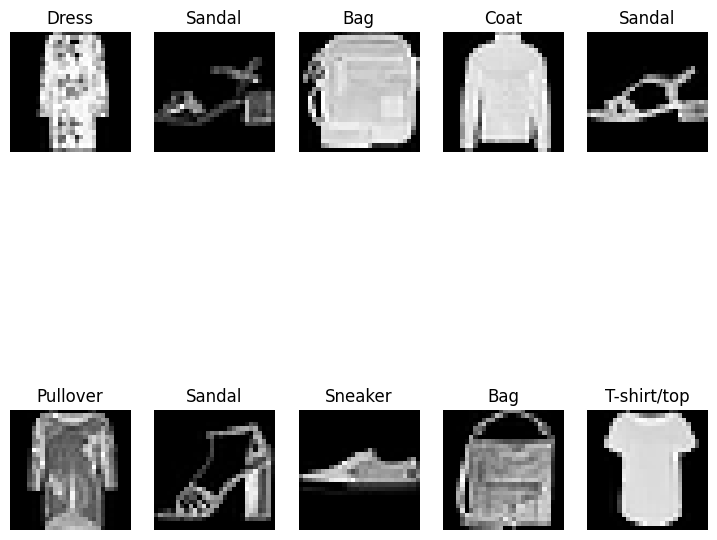

In [8]:
# plotting 10 images of the training data
figure = plt.figure(figsize=(9, 9))
cols, rows = 5, 2
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(class_names[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Plotting just the first image

Image shape: torch.Size([1, 28, 28])
Index and name of the label: 9 -> Ankle boot


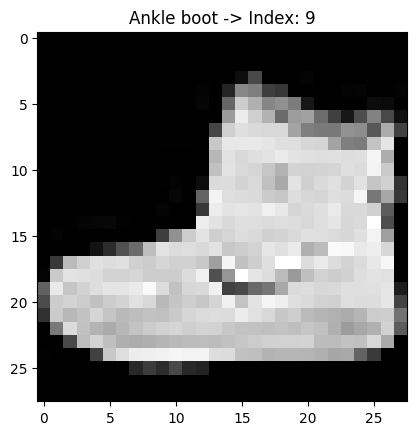

In [9]:
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Index and name of the label: {label} -> {class_names[label]}")
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"{class_names[label]} -> Index: {label}")
plt.show()

### Prepare the DataLoader
DataLoader converts a pytorch tensor into a python obejct (iterable)

In [10]:
from torch.utils.data import DataLoader

# set an appropriate batch size
BATCH_SIZE = 32

# create a DataLoader for the training data and test data
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

# printing the dataloaders
print(f"Dataloader for training data: {train_dataloader}")
print(f"Dataloader for test data: {test_dataloader}\n")

# checking the batch size and length of the dataloaders
print(f"Batch size of training dataloader: {train_dataloader.batch_size}")
print(f"Batch size of test dataloader: {test_dataloader.batch_size}\n")

# length of the dataloaders (number of batches)
print(f"Length of training dataloader: {len(train_dataloader)}")
print(f"Length of test dataloader: {len(test_dataloader)}")

Dataloader for training data: <torch.utils.data.dataloader.DataLoader object at 0x0000029D8EF65C50>
Dataloader for test data: <torch.utils.data.dataloader.DataLoader object at 0x0000029DC04CDBD0>

Batch size of training dataloader: 32
Batch size of test dataloader: 32

Length of training dataloader: 1875
Length of test dataloader: 313


In [11]:
# check out what's inside the training dataloader
train_batch_features, train_batch_labels = next(iter(train_dataloader))
print(f"{train_batch_features.shape} -> (batch_size, color_channels, height, width)")

torch.Size([32, 1, 28, 28]) -> (batch_size, color_channels, height, width)


Image Size: torch.Size([1, 28, 28])
Label: 0, label size: torch.Size([])


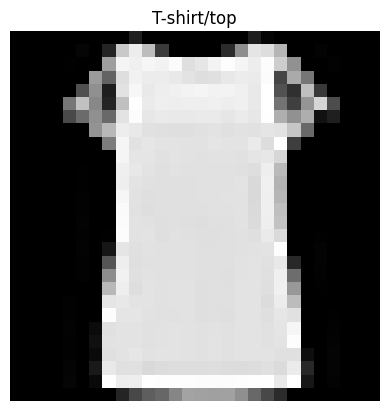

In [12]:
# Show a sample
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_batch_features), size=[1]).item()
img, label = train_batch_features[random_idx], train_batch_labels[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(class_names[label])
plt.axis(False)
print(f"Image Size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

### Build a baseline model `model_0`

In [13]:
# create a flatten layer
flatten_model = nn.Flatten()

# get a single sample
x = train_batch_features[0]

# flatten the sample
output = flatten_model(x) # perform forward pass

# printing what happened
print(f"Shape before flattening: {x.shape} -> (color_channels, height, width)")
print(f"Shape after flattening: {output.shape} -> (color_channels, height * width)")

Shape before flattening: torch.Size([1, 28, 28]) -> (color_channels, height, width)
Shape after flattening: torch.Size([1, 784]) -> (color_channels, height * width)


In [14]:
class FashionMNIST(nn.Module):
    def __init__(self, input_shape:int,
                 hidden_units:int,
                 output_shape:int):
        super().__init__()
        
        self.layer_stack = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )
    
    def forward(self, x):
        return self.layer_stack(x)

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [16]:
torch.manual_seed(42)

model_0 = FashionMNIST(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)

model_0

FashionMNIST(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [17]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0(dummy_x.to(device))

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], device='cuda:0', grad_fn=<AddmmBackward0>)

### Setup a loss function and an optimizer

In [18]:
import requests
from pathlib import Path

# download helper functions.py file
if Path("helper_functions.py").is_file():
    print("File already exists, skipping download")

else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

File already exists, skipping download


In [19]:
# import accuracy metric
from helper_functions import accuracy_fn

# setup loss function & optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

### Create a function to time the experiments

In [20]:
from timeit import default_timer as timer
def print_train_time(start:float, end:float, device:torch.device=None):
    """ Prints difference between start and end time."""
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

### Build a training and testing loop

In [21]:
from tqdm.auto import tqdm

# set the seed and start timer
torch.manual_seed(42)
start_time = timer()

# set number of epochs
epochs = 3

# create a training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"-------------------------Epoch: {epoch}--------------------------\n")
    
    # TRAINING
    train_loss = 0
    
    # add a loop to loop through the training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # set device agnostic 
        X, y = X.to(device), y.to(device)
        # 1. forward pass
        y_pred = model_0(X)
        
        # 2. calculate the loss (per)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulate the train loss
        
        # 3. optimizer zer grad
        optimizer.zero_grad()
        
        # 4. loss backward
        loss.backward()
        
        # 5. optimzer step...
        optimizer.step()
        
        # print what's happening
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide the total train loss by the length of the dataloader
    train_loss /= len(train_dataloader)

    
# Calculate the training time
end_time = timer()
total_train_time = print_train_time(start=start_time, end=end_time, device=str(next(model_0.parameters()).device))

c:\Users\DHYEY DESAI\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

-------------------------Epoch: 0--------------------------

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 33%|███▎      | 1/3 [00:48<01:37, 48.57s/it]

-------------------------Epoch: 1--------------------------

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 67%|██████▋   | 2/3 [01:28<00:43, 43.44s/it]

-------------------------Epoch: 2--------------------------

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 3/3 [02:17<00:00, 45.84s/it]

Train time on cuda:0: 137.540 seconds


### Setup device agnostic code

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Make Predictions using `model_0`

In [23]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.dataloader, 
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device=device):
    """ Returns a dictionary containing the results of predictions on dataloader """
    loss, acc = 0, 0
    model = model.to(device)
    model.eval()
    
    with torch.inference_mode():
        for X, y in tqdm(data_loader):
            # make the data device agnostic
            X, y = X.to(device), y.to(device)
            
            # make predictions
            y_pred = model(X)
            
            # accumulate the loss and acc values per batch
            loss += loss_fn(y_pred, y)
            
            acc += accuracy_fn(y_true=y,
                               y_pred=y_pred.argmax(dim=1))
            
        # scale loss and acc to find average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}
    
# Calculate the model_0 results on test dataset
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)

model_0_results

100%|██████████| 313/313 [00:08<00:00, 36.73it/s]


{'model_name': 'FashionMNIST',
 'model_loss': 0.5108761787414551,
 'model_acc': 82.37819488817891}

### Improving the model with non-linearity

In [24]:
class FashionMNIST_V2(nn.Module):
    def __init__(self, input_shape:int,
                 hidden_units:int,
                 output_shape:int):
        super().__init__()
        
        self.layer_stack = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )
    
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [25]:
# Create an instance of model_1
torch.manual_seed(42)
model_1 = FashionMNIST_V2(input_shape=784,
                          hidden_units=10,
                          output_shape=len(class_names)).to(device)

next(model_1.parameters()).device

device(type='cuda', index=0)

In [26]:
# ṣetup loss function, optimizer, and evaluation metrics
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [27]:
def train_model(model: torch.nn.Module,
                data_loader: torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                optimizer: torch.optim,
                accuracy_fn,
                device: torch.device=device):
    
    train_loss, train_acc = 0, 0
    
    # put model in training mode
    model.train()
    
    for epoch in tqdm(range(epochs)):
        # print(f"------------------------- Epoch: {epoch} --------------------------\n")
        
        # TRAINING
        train_loss = 0
        
        # add a loop to loop through the training batches
        for batch, (X, y) in enumerate(data_loader):
            
            # put data on target device
            X, y = X.to(device), y.to(device)
            
            # 1. forward pass (outputs raw logits)
            y_pred = model(X)
            
            # 2. calculate the loss (per)
            loss = loss_fn(y_pred, y)
            train_loss += loss # accumulate the train loss
            train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1)) # go from raw logits -> prediction labels
            
            # 3. optimizer zero grad
            optimizer.zero_grad()
            
            # 4. loss backward
            loss.backward()
            
            # 5. optimzer step...
            optimizer.step()
            

        # Divide the total train loss and accuracy by the length of the dataloader
        train_loss /= len(data_loader)
        train_acc /= len(data_loader)
        
        # print what's happening
        if batch % 400 == 0:
            print(f"Train Loss: {train_loss:.5f} | Train Acc: {train_acc:.2f}%")

In [28]:
def test_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim,
               accuracy_fn,
               device: torch.device=device):
    
    # TESTING
    test_loss, test_acc = 0, 0
    
    # put the model on evaluation mode
    model.eval()
    
    # turn on inference mode context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # send data to target device
            X, y = X.to(device), y.to(device)
            
            # 1. forward pass
            test_pred = model(X)
            
            # 2. calculate the loss
            test_loss += loss_fn(test_pred, y)
            
            # 3. calculate accuracy
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1)) # go from raw logits -> prediction labels
        
        # Calculate the test loss (average per batch)
        test_loss /= len(data_loader)
        
        # Calculate the test accuracy (average per batch)
        test_acc /= len(data_loader)
    
    # Print what's happening
    print(f"\nTrain Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}")

In [29]:
torch.manual_seed(42)

# Measure the start time
from timeit import default_timer as timer
start = timer()

# set epochs
epochs = 3

# Create an optimization and evaluation loop using the train and test functions
for epoch in tqdm(range(epochs)):
    print(f"------------------------ Epoch: {epoch} -----------------------\n")
    train_model(model=model_1, 
                data_loader=train_dataloader, 
                loss_fn=loss_fn,
                optimizer=optimizer,
                accuracy_fn=accuracy_fn,
                device=device)
    
    test_model(model=model_1,
               data_loader=test_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)
    
# measure end time
end = timer()
total_train_time_model_1 = print_train_time(start=start, end=end, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

------------------------ Epoch: 0 -----------------------



 33%|███▎      | 1/3 [04:26<08:52, 266.27s/it]


Train Loss: 0.4532 | Test Loss: 0.6889 | Test Accuracy: 74.98
------------------------ Epoch: 1 -----------------------



 67%|██████▋   | 2/3 [07:41<03:44, 224.24s/it]


Train Loss: 0.4532 | Test Loss: 0.7264 | Test Accuracy: 73.02
------------------------ Epoch: 2 -----------------------



100%|██████████| 3/3 [10:52<00:00, 217.39s/it]


Train Loss: 0.4532 | Test Loss: 0.4429 | Test Accuracy: 84.38
Train time on cuda: 652.195 seconds


In [30]:
model_1_results = eval_model(model=model_1, 
                             data_loader=test_dataloader, 
                             loss_fn=loss_fn, 
                             accuracy_fn=accuracy_fn)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

100%|██████████| 313/313 [00:09<00:00, 33.39it/s]


{'model_name': 'FashionMNIST_V2',
 'model_loss': 0.4429354965686798,
 'model_acc': 84.375}

In [31]:
model_0_results

{'model_name': 'FashionMNIST',
 'model_loss': 0.5108761787414551,
 'model_acc': 82.37819488817891}

In [32]:
# Create a convolutional neural network 
class FashionMNISTModelV3(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_1 = nn.Sequential(
            # Create a conv layer
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.conv_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.classifer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )
        
    def forward(self, x):
        x = self.conv_1(x)
        # print(x.shape)
        x = self.conv_2(x)
        # print(x.shape)
        x = self.classifer(x)
        return x
    

In [33]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV3(
    input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)

In [34]:
rand_image_tensor = torch.randn(size=(1, 28, 28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [35]:
model_2(rand_image_tensor.unsqueeze(0).to(device))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], device='cuda:0', grad_fn=<AddmmBackward0>)

### Stepping through `nn.Conv2d()`

In [36]:
torch.manual_seed(42)

# Create a batch of images
images = torch.randn(size=(32, 3 ,64, 64))
test_image = images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image: \n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image: 
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0

In [37]:
torch.manual_seed(42)

# Create a single conv2d layer
conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=(3, 3),
    stride=1,
    padding=1
)

# pass the data to the convolutional layer
conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 64, 64])

### Stepping through `nn.MaxPool2d()`

In [38]:
# Print out original image shape without unsqueezed dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(0).shape}")

# create a sample nn.MaxPool2d() layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data thorugh just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer: {test_image_through_conv.shape}")

# pass data through max_pool_layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"SHape after going through the max_pool_layer: {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer: torch.Size([1, 10, 64, 64])
SHape after going through the max_pool_layer: torch.Size([1, 10, 32, 32])


In [39]:
torch.manual_seed(42)

# Create a random tensor with similar dimension to our images
random_tensor = torch.randn(size=(1, 1, 2, 2))

# Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)

print(f"\nMax pool tensor: {max_pool_tensor}")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")

print(f"\nRandom Tensor:\n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")


Max pool tensor: tensor([[[[0.3367]]]])
Max pool tensor shape: torch.Size([1, 1, 1, 1])

Random Tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])


### Setup a loss function and an optimizer for `model_2`

In [40]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [42]:
# Train and test the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)


# calculate the time
start = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    # TRAINING
    train_model(model=model_2,
                data_loader=train_dataloader,
                loss_fn=loss_fn, 
                optimizer=optimizer,
                accuracy_fn=accuracy_fn,
                device=device)

    # TESTING
    test_model(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device=device)

end = timer()
total_time = print_train_time(start=start, end=end, device=device)

 33%|███▎      | 1/3 [01:31<03:02, 91.23s/it]


Train Loss: 0.4532 | Test Loss: 0.3325 | Test Accuracy: 87.67


 67%|██████▋   | 2/3 [02:47<01:22, 82.55s/it]


Train Loss: 0.4532 | Test Loss: 0.3434 | Test Accuracy: 87.61


100%|██████████| 3/3 [03:34<00:00, 71.63s/it]


Train Loss: 0.4532 | Test Loss: 0.2841 | Test Accuracy: 89.77
Train time on cuda: 214.885 seconds


In [43]:
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)

model_2_results

100%|██████████| 313/313 [00:02<00:00, 113.71it/s]


{'model_name': 'FashionMNISTModelV3',
 'model_loss': 0.2841376066207886,
 'model_acc': 89.76637380191693}

### Compare the model's results and training time

In [44]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNIST,0.510876,82.378195
1,FashionMNIST_V2,0.442935,84.375000
2,FashionMNISTModelV3,0.284138,89.766374


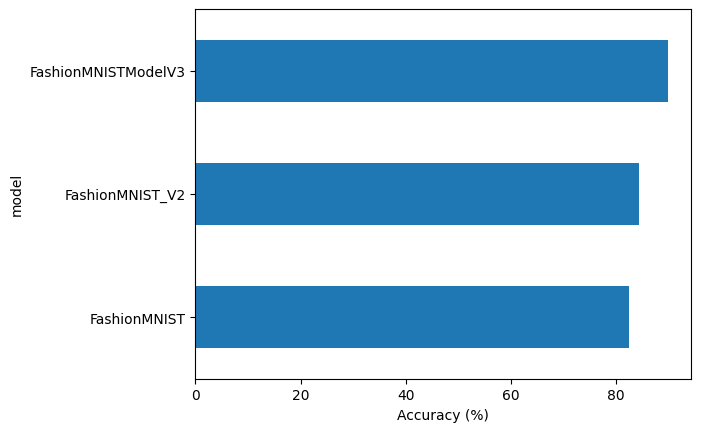

In [45]:
# visualize model results

compare_results.set_index('model_name')['model_acc'].plot(kind='barh')
plt.xlabel('Accuracy (%)');
plt.ylabel("model");

### Make and evaluate random predictions from the best model

In [46]:
def make_predictions(model: torch.nn.Module, 
                     data: list,
                     device: torch.device=device):
    
    pred_probs = []
    model.to(device)
    
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # prepare the sample (add a batch dimension and pass it to target device)
            sample = torch.unsqueeze(sample, dim=0).to(device)
            
            # forward pass (it outputs raw logits)
            pred_logit = model(sample)
            
            # get prediction probability (logit -> predictuion probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            
            # get pred_prob off the GPU for further calculations
            pred_probs.append(pred_prob.cpu())
            
    # stack the pred_probs to turn a list to a tensor
    return torch.stack(pred_probs)

In [47]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [74]:
import random
# random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)
    
# view the first sample image
test_samples[0].shape

torch.Size([1, 28, 28])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

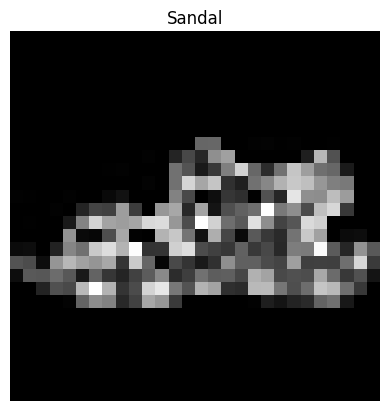

In [80]:
plt.imshow(test_samples[0].squeeze(), cmap='gray')
plt.title(class_names[test_labels[0]])
plt.axis(False)

In [81]:
# Make predictions
pred_probs = make_predictions(model=model_2,
                              data=test_samples)

# view the first 2 prediction =prbabilities
pred_probs[:2]

tensor([[2.9165e-07, 1.0237e-08, 1.5085e-07, 1.4611e-09, 2.5663e-07, 9.9999e-01,
         9.6682e-07, 6.0434e-06, 5.1270e-06, 9.3915e-07],
        [6.5065e-03, 7.1828e-07, 8.6969e-03, 2.5354e-05, 1.9520e-02, 1.5348e-07,
         9.6524e-01, 9.3236e-08, 5.8280e-06, 2.0494e-07]])

In [82]:
test_labels

[5, 6, 6, 4, 3, 1, 4, 6, 6]

In [83]:
# convert prediction prabilities into labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 6, 6, 4, 3, 3, 4, 3, 6])

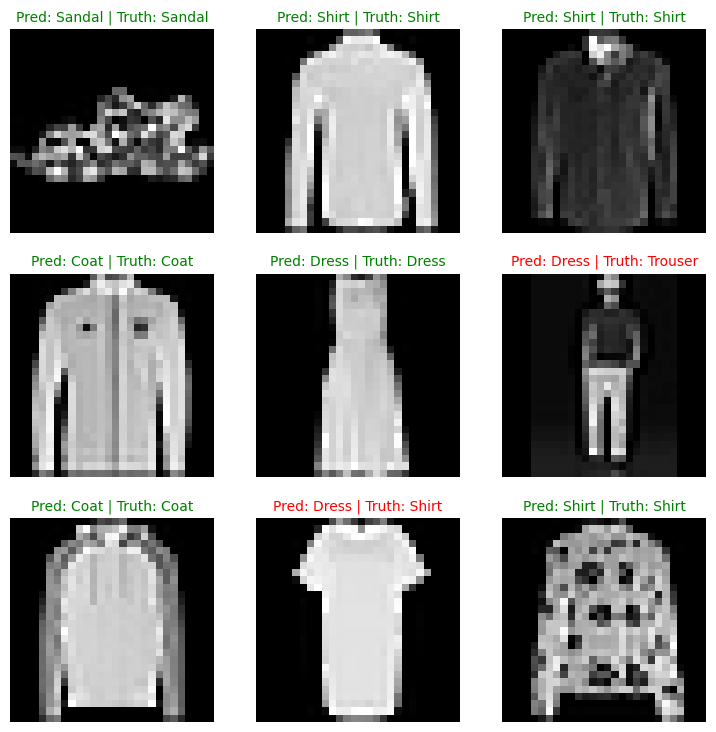

In [85]:
# plot the predictions
plt.figure(figsize=(9, 9))
nrows=3
ncols=3

for i, sample in enumerate(test_samples):
    # create a subplot
    plt.subplot(nrows, ncols, i+1)
    
    # plot the target sample
    plt.imshow(sample.squeeze(), cmap='gray')
    
    # find the prediction (in text form)
    pred_label = class_names[pred_classes[i]]
    
    # get the truth label (in text form)
    turth_label = class_names[test_labels[i]]
    
    # create a title for the plot
    title_text = f"Pred: {pred_label} | Truth: {turth_label}"
    
    # check for equality between pred and truth and change color of title text
    if pred_label == turth_label:
        plt.title(title_text, fontsize=10, c='g')
    
    else:
        plt.title(title_text, fontsize=10, c='r')
        
    plt.axis(False);